
<a id='chap-tpacp'></a>

# Travaux pratiques - Analyse en composantes principales

(correspond à 1 séance de TP)

Références externes utiles :

> - [Documentation NumPy](https://docs.scipy.org/doc/numpy/user/index.html)  
- [Documentation SciPy](https://docs.scipy.org/doc/scipy/reference/)  
- [Documentation MatPlotLib](http://matplotlib.org/)  
- [Site scikit-learn](http://scikit-learn.org/stable/index.html)  
- [Site langage python](https://www.python.org)  



**L’objectif** de cette séance de TP est de présenter l’utilisation des fonctionnalités de Scikit-learn concernant l’ACP, ainsi que de contribuer à une meilleure compréhension de cette méthode d’analyse de données. Après une brève présentation de la classe correspondante de Scikit-learn, nous examinons d’abord des données générées de façon contrôlée afin de mieux comprendre l’impact de la distribution des données sur les résultats de l’ACP. Deux exemples du cours, basés sur des données réelles, sont ensuite repris et examinés.

## L’ACP dans Scikit-learn

Dans Scikit-learn, l’analyse en composantes principales (ACP) est mise en œuvre dans la classe `sklearn.decomposition.PCA` (voir [http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html](http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)). Les variantes et quelques exemples sont présentés sur [http://scikit-learn.org/stable/modules/decomposition.html](http://scikit-learn.org/stable/modules/decomposition.html).

Pour définir l’analyse on appelle `PCA(n_components=None, copy=True, whiten=False, svd_solver='auto', tol=0.0, iterated_power='auto', random_state=None)`. Les paramètres d’appel sont (pour des explications plus détaillées voir le lien ci-dessus) :

> - `n_components` : nombre de composantes à conserver (par défaut toutes, c’est à dire `min(n_samples, n_features)` où `n_samples` est le nombre de lignes de la matrice de données et `n_features` le nombre de colonnes).  
- `copy` : si `False`, la matrice de données est écrasée par les données transformées (par défaut `True`).  
- `whiten` : si `True`, les données transformées sont modifiées pour que les projections sur les axes principaux présentent une variance unitaire (par défaut `False`).  
- `svd_solver` : solveur à employer parmi `'auto'`, `'full'`, `'arpack'`, `'randomized'` (par défaut `'auto'`).  
- `tol`, `iterated_power`, `random_state` : paramètres optionnels pour solveurs spécifiques.  



Les attributs accessibles sont les suivants :

> - `explained_variance_` : array `[n_components]` dans lequel on trouve les valeurs propres en ordre décroissant.  
- `components_` : array `[n_components, n_features]` dans lequel chaque ligne correspond à un vecteur propre ; l’ordre est celui des valeurs propres.  
- `explained_variance_ratio_` : array `[n_components]` avec les valeurs propres exprimées en pourcentage de la variance expliquée.  
- `mean_` : array `[n_features]` contenant les moyennes des variables calculées lors de l’ACP.  
- `n_components_` : nombre estimé de composantes.  
- `noise_variance_` : variance du bruit estimée suivant l’approche de l’ACP probabiliste (voir lien ci-dessus).  



Les méthodes qui peuvent être employées :

> - `fit(X[, y])` : trouver les axes principaux et les valeurs propres associés à partir de la matrice de données X.  
- `fit_transform(X[, y])` : trouver les axes principaux et les valeurs propres associés, appliquer la projection sur les axes principaux (avec stockage des résultats dans la matrice de données X si `copy=False` et dans une autre matrice si `copy=True`).  
- `get_covariance()` : calculer les covariances à partir de la matrice de données.  
- `get_params([deep])` : retourner les paramètres de l’estimateur.  
- `get_precision()` : calculer la matrice de précision des données.  
- `inverse_transform(X[, y])` : re-projeter les données transformées dans l’espace initial.  
- `score(X[, y])` : valeur moyenne de la log-vraisemblance pour toutes les observations.  
- `score_samples(X)` : log-vraisemblance pour chaque observation.  
- `set_params(**params)` : donner des valeurs aux paramètres de l’estimateur.  
- `transform(X[, y])` : appliquer la projection sur les axes principaux (avec stockage des résultats dans la matrice de données X si `copy=False` et dans une autre matrice si `copy=True`).  

## ACP de données générées

Démarrez par la génération d’un ensemble de 500 vecteurs dans l’espace 3D, suivant une loi normale (de moyenne nulle et de variance unitaire), ensuite visualisez les points générés :

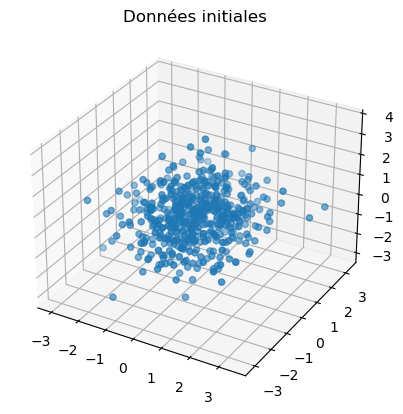

In [1]:
import numpy as np
from scipy.stats import norm
# Génération de données selon une loi normale tridimensionnelle
rndn3d = np.random.randn(500,3)
#rndn3d = norm.rvs(0,1,500).reshape(3)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Affichage du nuage de points
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rndn3d[:,0], rndn3d[:,1], rndn3d[:,2])
plt.title("Données initiales")
plt.show()

Appliquez ensuite l’ACP à ces données :

In [2]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca.fit(rndn3d)

print("Pourcentage de variance expliquée : ")
print(pca.explained_variance_ratio_)
print("Composantes principales : ")
print(pca.components_)

Pourcentage de variance expliquée : 
[0.38311042 0.31944513 0.29744445]
Composantes principales : 
[[ 0.46455994  0.77612712  0.42639273]
 [-0.53294447  0.62958288 -0.56532787]
 [ 0.70721585 -0.03538503 -0.70611164]]


Chaque ligne de `pca.components_` représente le vecteur unitaire qui donne la direction d’un axe factoriel. Le vecteur `pca.components_[i,:]` correspond à la valeur propre `pca.explained_variance_ratio_[i]`.

## Question :

Générez un **autre** tableau de données en utilisant de nouveau `np.random.randn(500,3)` et appliquez l’ACP à ces nouvelles données. Comparez les résultats avec ceux obtenus sur `rndn3d`. Que constatez-vous ? Expliquez.

Appliquez maintenant une déformation et une rotation dans l’espace tridimensionnel au nuage des observations de `rndn3d`, visualisez le résultat :

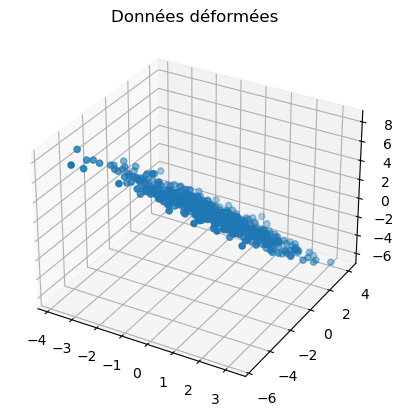

In [8]:
s1 = np.array([[3,0,0],[0,1,0],[0,0,0.2]])  # matrice de déformation
r1 = np.array([[0.36,0.48,-0.8],[-0.8,0.6,0],[0.48,0.64,0.6]])  # matrice de rotation
rndef = rndn3d.dot(s1).dot(r1)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(rndef[:,0], rndef[:,1], rndef[:,2])
plt.title("Données déformées")
plt.show()

Appliquez une ACP à ces observations :

In [3]:
pca = PCA(n_components=3)
pca.fit(rndef)

print("Pourcentage de variance expliquée : ")
print(pca.explained_variance_ratio_)
print("Composantes principales : ")
print(pca.components_)

NameError: name 'rndef' is not defined

## Question :

Que constatez-vous par rapport à l’application directe de l’ACP sur les données de `rndn3d` ? Expliquez. Peut-on lier les rapports entre les valeurs propres obtenues aux rapports entre les éléments de la diagonale de la matrice de déformation `s1` ?

## Question :

Générez un autre ensemble de données en utilisant les mêmes matrices de transformation et appliquez l’ACP à ces nouvelles données. Comparez les résultats avec ceux obtenus sur `rndef`. Que constatez-vous ? Expliquez.

## ACP des données sur le sommeil des mammifères

L’ACP sera d’abord appliquée aux données concernant le sommeil des mammifères, issues de [[AC76]](#ac76) et déjà vues dans le cours. Pour cela, il est d’abord nécessaire d’enregistrer ces données dans le répertoire de travail. Dans une fenêtre terminal entrez (ou télécharger le fichier via [ce lien](http://cedric.cnam.fr/~crucianm/src/mammals.csv)):

In [16]:


import os

# Obtenir le nom de l'utilisateur actuel
current_user = os.getlogin()
print(f"Utilisateur actuel : {current_user}")

current_directory = os.getcwd()
print(f"Vous êtes dans le répertoire : {current_directory}")

!wget -nc http://cedric.cnam.fr/~crucianm/src/mammals.csv


Utilisateur actuel : fred
Vous êtes dans le répertoire : /home/fred/partage/Workspace/RCP208
--2025-01-12 12:24:30--  http://cedric.cnam.fr/~crucianm/src/mammals.csv
Résolution de cedric.cnam.fr (cedric.cnam.fr)… 163.173.128.10
Connexion à cedric.cnam.fr (cedric.cnam.fr)|163.173.128.10|:80… connecté.
requête HTTP transmise, en attente de la réponse… 200 OK
Taille : 3138 (3,1K) [text/x-comma-separated-values]
Sauvegarde en : « mammals.csv »

mammals.csv         100%[===================>]   3,06K  --.-KB/s    ds 0s      

2025-01-12 12:24:30 (155 MB/s) — « mammals.csv » sauvegardé [3138/3138]



Vous pouvez examiner le contenu de ce fichier format `.csv`. Les données doivent être ensuite lues dans Python :

In [17]:
mammals = np.loadtxt('mammals.csv', delimiter=';', usecols=[1,2,3,4,5,6,7,8,9,10], skiprows=1)
print(mammals[:2,:])
noms = np.genfromtxt('mammals.csv', dtype='str', delimiter=';', usecols=[0], skip_header=1)
print(mammals)

[[6.654e+03 5.712e+03 8.350e+00 1.800e+00 3.300e+00 3.860e+01 6.450e+02
  3.000e+00 5.000e+00 3.000e+00]
 [1.000e+00 6.600e+00 6.300e+00 2.000e+00 8.300e+00 4.500e+00 4.200e+01
  3.000e+00 1.000e+00 3.000e+00]]
[[6.654e+03 5.712e+03 8.350e+00 1.800e+00 3.300e+00 3.860e+01 6.450e+02
  3.000e+00 5.000e+00 3.000e+00]
 [1.000e+00 6.600e+00 6.300e+00 2.000e+00 8.300e+00 4.500e+00 4.200e+01
  3.000e+00 1.000e+00 3.000e+00]
 [3.385e+00 4.450e+01 8.350e+00 1.800e+00 1.250e+01 1.400e+01 6.000e+01
  1.000e+00 1.000e+00 1.000e+00]
 [9.200e-01 5.700e+00 8.350e+00 1.800e+00 1.650e+01 1.510e+01 2.500e+01
  5.000e+00 2.000e+00 3.000e+00]
 [2.547e+03 4.603e+03 2.100e+00 1.800e+00 3.900e+00 6.900e+01 6.240e+02
  3.000e+00 5.000e+00 4.000e+00]
 [1.055e+01 1.795e+02 9.100e+00 7.000e-01 9.800e+00 2.700e+01 1.800e+02
  4.000e+00 4.000e+00 4.000e+00]
 [2.300e-02 3.000e-01 1.580e+01 3.900e+00 1.970e+01 1.900e+01 3.500e+01
  1.000e+00 1.000e+00 1.000e+00]
 [1.600e+02 1.690e+02 5.200e+00 1.000e+00 6.200e+00 3.

In [18]:
mammals = np.loadtxt('mammals.csv', delimiter=';', usecols=[1,2,3,4,5,6,7,8,9,10], skiprows=1)
print(mammals[:2,:])
noms = np.genfromtxt('mammals.csv', dtype='str', delimiter=';', usecols=[0], skip_header=1)
print(mammals)

[[6.654e+03 5.712e+03 8.350e+00 1.800e+00 3.300e+00 3.860e+01 6.450e+02
  3.000e+00 5.000e+00 3.000e+00]
 [1.000e+00 6.600e+00 6.300e+00 2.000e+00 8.300e+00 4.500e+00 4.200e+01
  3.000e+00 1.000e+00 3.000e+00]]
[[6.654e+03 5.712e+03 8.350e+00 1.800e+00 3.300e+00 3.860e+01 6.450e+02
  3.000e+00 5.000e+00 3.000e+00]
 [1.000e+00 6.600e+00 6.300e+00 2.000e+00 8.300e+00 4.500e+00 4.200e+01
  3.000e+00 1.000e+00 3.000e+00]
 [3.385e+00 4.450e+01 8.350e+00 1.800e+00 1.250e+01 1.400e+01 6.000e+01
  1.000e+00 1.000e+00 1.000e+00]
 [9.200e-01 5.700e+00 8.350e+00 1.800e+00 1.650e+01 1.510e+01 2.500e+01
  5.000e+00 2.000e+00 3.000e+00]
 [2.547e+03 4.603e+03 2.100e+00 1.800e+00 3.900e+00 6.900e+01 6.240e+02
  3.000e+00 5.000e+00 4.000e+00]
 [1.055e+01 1.795e+02 9.100e+00 7.000e-01 9.800e+00 2.700e+01 1.800e+02
  4.000e+00 4.000e+00 4.000e+00]
 [2.300e-02 3.000e-01 1.580e+01 3.900e+00 1.970e+01 1.900e+01 3.500e+01
  1.000e+00 1.000e+00 1.000e+00]
 [1.600e+02 1.690e+02 5.200e+00 1.000e+00 6.200e+00 3.

## Question :

Appliquez une ACP aux données de `mammals` et affichez les valeurs propres. Comparez les deux premières aux valeurs vues en cours. Que constatez-vous ? Pourquoi ?

In [19]:
#test matrice initiale multiplié par transposé = matrice de covariance avec numpy
import numpy as np
from sklearn import preprocessing

mammalsNorm = mammals-np.mean(mammals, axis=0)
mammalsNorm = mammalsNorm/np.std(mammals, axis=0)


#scaler = preprocessing.StandardScaler().fit(mammals)
#mammalsNorm = scaler.transform(mammals)


#mammalsFit = preprocessing.scale(mammals)
transposé = np.transpose(mammalsNorm)
xtx=transposé.dot(mammalsNorm)

#calul valeurs propres et vecteur propre
vpvp = np.linalg.eig(xtx)
print(vpvp[0])


#!!!!!! vecteur propre de XTX est est differente des ceux calculé avec ACP, pourquoi  !!!!!


[297.70865127 136.88871348  78.15541104  40.22601745  29.38215051
  16.16863359  11.14601452   1.50547193   3.10888396   5.71005224]


In [20]:
pca = PCA(n_components=10)
pca.fit(mammals)

print("Pourcentage de variance expliquée : ")
print(pca.explained_variance_ratio_)

print("variance expliquée : ")
print(pca.explained_variance_)

print("Valeur propres : ")
print(pca.singular_values_)


print("Composantes principales : ")
print(pca.components_)

#Valeurs propres differzente du cours car matrice non centrée reduite


Pourcentage de variance expliquée : 
[9.61492649e-01 3.35026815e-02 4.90760735e-03 8.11547630e-05
 1.21589728e-05 2.12907093e-06 8.08341160e-07 4.40101019e-07
 3.18913491e-07 5.23943276e-08]
variance expliquée : 
[1.62938255e+06 5.67749369e+04 8.31662079e+03 1.37527993e+02
 2.06050646e+01 3.60800575e+00 1.36984612e+00 7.45812170e-01
 5.40443109e-01 8.87894494e-02]
Valeur propres : 
[9.96957047e+03 1.86098661e+03 7.12259691e+02 9.15926175e+01
 3.54529116e+01 1.48353750e+01 9.14114946e+00 6.74496422e+00
 5.74169223e+00 2.32726372e+00]
Composantes principales : 
[[ 6.91530256e-01  7.17839107e-01 -5.17706454e-04 -7.03276614e-05
  -1.19061030e-03  5.83095626e-03  8.03554134e-02  5.62370320e-05
   4.56367148e-04  1.63599468e-04]
 [ 7.17643324e-01 -6.70475912e-01  3.99681169e-03  5.47535865e-04
   3.13415007e-03 -4.31881591e-02 -1.83188214e-01  3.04585283e-04
  -7.97595986e-04 -3.81774286e-04]
 [ 7.87526498e-02 -1.85746381e-01 -1.13229256e-02 -6.46737272e-03
  -2.11245822e-02  4.01418913e-02 

## Question :

Appliquez une transformation de centrage et réduction aux variables décrivant les données de `mammals` (regardez [le centrage et la réduction des variables (« standardization ») avec scikit-learn](http://scikit-learn.org/stable/modules/preprocessing.html#standardization-or-mean-removal-and-variance-scaling)) et conservez le résultat dans `mammalsCR`. Appliquez de nouveau l’ACP, de préférence en utilisant une nouvelle instance `pcaCR` pour conserver `pca`. Comment ont évolué les valeurs propres les plus grandes ? Affichez le graphique de décroissance des valeurs propres.

<function matplotlib.pyplot.show(close=None, block=None)>

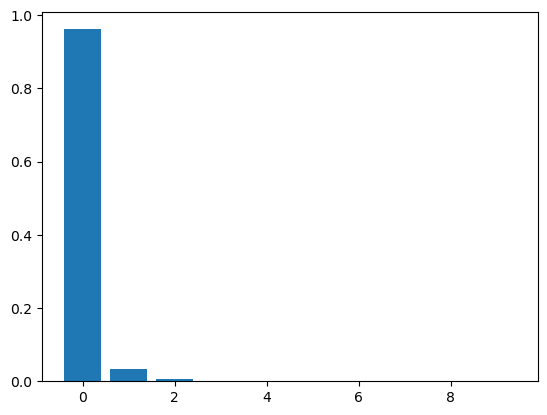

In [21]:
values = pca.explained_variance_ratio_
plt.bar(range(len(values)), values)
plt.show


Pourcentage de variance expliquée : 
[0.48017524 0.22078825 0.12605711 0.06488067 0.04739057 0.02607844
 0.01797744 0.00920976 0.00501433 0.00242818]
variance expliquée : 
[1.62938255e+06 5.67749369e+04 8.31662079e+03 1.37527993e+02
 2.06050646e+01 3.60800575e+00 1.36984612e+00 7.45812170e-01
 5.40443109e-01 8.87894494e-02]
Valeur propres : 
[9.96957047e+03 1.86098661e+03 7.12259691e+02 9.15926175e+01
 3.54529116e+01 1.48353750e+01 9.14114946e+00 6.74496422e+00
 5.74169223e+00 2.32726372e+00]
Composantes principales : 
[[-2.50732797e-01 -2.83386185e-01  3.21119835e-01  2.90608165e-01
   3.85381586e-01 -2.48280014e-01 -3.73362207e-01 -2.54236784e-01
  -3.81271444e-01 -3.31192928e-01]
 [ 4.41774804e-01  4.74780540e-01  9.76908526e-02  2.36799163e-01
   9.11304370e-02  3.03840086e-01  2.66729028e-01 -4.25882432e-01
  -1.36112966e-01 -3.77002122e-01]
 [ 3.39765787e-01  2.25583585e-01  4.56419300e-01  3.13282077e-01
   3.27001360e-01 -3.45426476e-01  5.52295975e-02  4.06760236e-01
   1.9569

<function matplotlib.pyplot.show(close=None, block=None)>

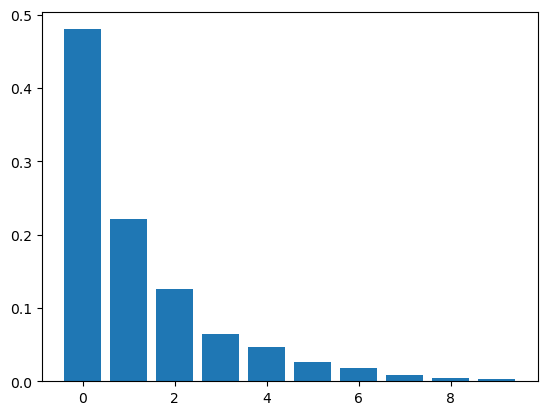

In [22]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler().fit(mammals)
#Centrage et reduction
mammalsCR = scaler.transform(mammals)
pcaCR = PCA(n_components=10)
pcaCR.fit(mammalsCR)

print("Pourcentage de variance expliquée : ")
print(pcaCR.explained_variance_ratio_)


print("variance expliquée : ")
print(pca.explained_variance_)

print("Valeur propres : ")
print(pca.singular_values_)


print("Composantes principales : ")
print(pcaCR.components_)

values2 = pcaCR.explained_variance_ratio_
plt.bar(range(len(values2)), values2)
plt.show


Nous pouvons maintenant obtenir et afficher les projections des observations sur les deux premiers axes factoriels. Rappelons que `mammalsCR` contient les données transformées (variables centrées et réduites) et que `pcaCR` est l’instance de PCA utilisée pour analyser `mammalsCR` ; `mammalsCR` et `pcaCR` ont été obtenues en réponse à la question ci-dessus.

In [23]:
mNt = pcaCR.transform(mammalsCR)
print(mNt[:2,:])

[[-6.50530263  6.7330641   3.43983054 -2.05458566 -1.38117895 -0.06000125
  -0.66178241 -0.31378774 -0.37607103 -0.30709013]
 [ 0.42443283 -0.80647942 -0.41704187 -1.29587063  0.09294702 -0.39025445
   0.16477426 -0.09485348  0.31128589 -0.1266842 ]]


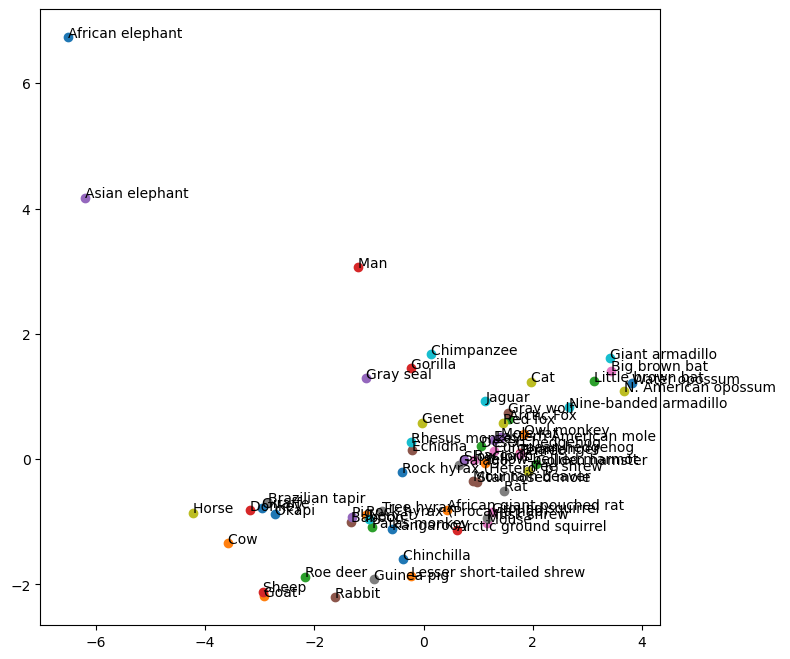

In [24]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111)
for i in range(len(noms)):
        x,y = mNt[i,0], mNt[i,1]
        ax.scatter(x,y)
        ax.text(x,y,noms[i])

plt.show()

## Question :

Réalisez l’affichage des projections sur les **3** premiers axes principaux ; la possibilité de rotation du graphique facilite la lecture des étiquettes textuelles.

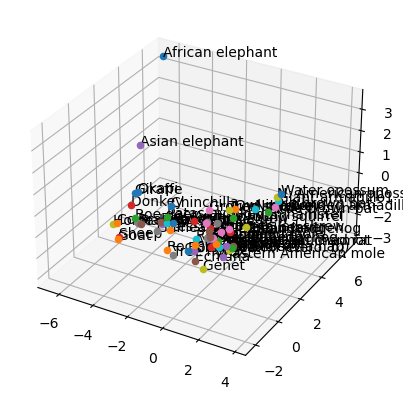

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for i in range(len(noms)):
        x,y,z = mNt[i,0], mNt[i,1], mNt[i,2]
        ax.scatter(x,y,z)
        ax.text(x,y,z,noms[i])

plt.show()

## Question :

Les résultats de l’analyse du nuage des variables ne sont pas directement disponibles. Comment pouvez-vous les obtenir ? Affichez la projection du nuage des variables sur les deux premiers axes factoriels.

## ACP sur les données « feuilles »

Nous appliquerons maintenant l’ACP sur les données concernant des feuilles d’arbres, issues de [https://archive.ics.uci.edu/ml/datasets/Leaf](https://archive.ics.uci.edu/ml/datasets/Leaf). Pour cela, il est d’abord nécessaire d’enregistrer ces données dans le répertoire de travail. Dans une fenêtre terminal entrez (ou téléchargez depuis [cette adresse](http://cedric.cnam.fr/~crucianm/src/leaf.csv):

In [ ]:
!wget -nc http://cedric.cnam.fr/~crucianm/src/leaf.csv



Examinez le fichier téléchargé et regardez sur le site indiqué les explications concernant le format des données.

Appliquez l’ACP aux données et affichez la décroissance des valeurs propres :

In [ ]:
import numpy as np
from scipy.stats import norm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

leaf = np.loadtxt('leaf.csv', delimiter=',')
print(leaf[:2,:])

from sklearn import preprocessing
leafN = preprocessing.scale(leaf[:,2:])
pca = PCA()
pca.fit(leafN)

ratios = pca.explained_variance_ratio_
plt.bar(range(len(ratios)), pca.explained_variance_ratio_)
plt.xticks(range(len(ratios)))
plt.xlabel("Composante principale")
plt.ylabel("% de variance expliquée")
plt.show()

## Question :

Affichez les projections des données sur les 3 premiers axes principaux.

In [ ]:
MatriceN = pca.transform(leaf[:,2:])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for i in np.arange(MatriceN.shape[0]):
        x,y,z = MatriceN[i,0], MatriceN[i,1], MatriceN[i,2]
        ax.scatter(x,y,z)
        #ax.text(x,y,z,MatriceN[i])

plt.show()

## Question :

Affichez les projections des données sur les 3 premiers axes principaux en utilisant l’étiquette de classe pour donner une couleur aux marques. L’étiquette de classe se trouve (sous forme numérique) dans la première colonne de `leaf`. Il est nécessaire d’ajouter dans l’appel `ax.scatter` un argument pour indiquer que la couleur est obtenue à partir de données, `c = ...`.

In [ ]:
import random

def generer_couleur_aleatoire():
    return [random.random() for _ in range(3)] 

#associer couleur à classe
classecoul ={}
for i in leaf[:,0]:
    if i not in classecoul.keys():
           classecoul[i]= generer_couleur_aleatoire()

            
#50 premieres valeurs de la liste pour ne pas surcharger  le tableau
MatriceN = pca.transform(leaf[:,2:])[:50,:]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for i in np.arange(MatriceN.shape[0]):
        x,y,z = MatriceN[i,0], MatriceN[i,1], MatriceN[i,2]
        ax.scatter(x,y,z, c=classecoul[leaf[i,0]])
        #ax.text(x,y,z,MatriceN[i])

plt.show()

<a id='ac76'></a>
\[AC76\] Allison T., D. Cicchetti. *Sleep in mammals: ecological and constitutional correlates*. *Science*, 194: 732–734 (1976).